In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("olist_order_payments_dataset_cle.csv")
df.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [4]:
df.dtypes

order_id                object
payment_sequential       int64
payment_type            object
payment_installments     int64
payment_value           object
dtype: object

In [7]:
df["payment_value"].unique()

array(['99.33', '24.39', '65.71', ..., '205.71', '100.55', '363.31'],
      dtype=object)

In [46]:
df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
 payment_value          0
dtype: int64

In [78]:
df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [77]:
df.dropna(subset=["payment_value"], inplace=True)

In [70]:
df["payment_value"] = df["payment_value"].astype(float)

In [8]:
df = df.rename(columns={"payment_value " : "payment_value"})

In [81]:
df["payment_value"].mean()

154.11373181743792

In [82]:
df["payment_value"].max()

13664.08

In [83]:
df["payment_value"].min()

0.01

Text(0, 0.5, ' ')

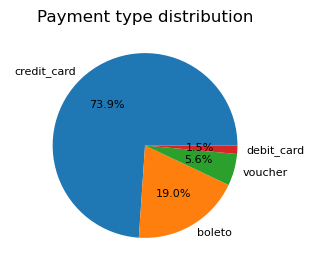

In [91]:
df["payment_type"].value_counts().plot(
    kind="pie",
    title="Payment type distribution",
    figsize=(5,3),
    color=["green","lightgreen","grey","lightgrey"],
    autopct="%1.1f%%",
    fontsize=8
)
plt.ylabel(" ")


credit card is mostly used as the payment type 73.9%

In [92]:
df.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [103]:
(df["payment_sequential"].value_counts(normalize=True)*100).round(2).head(10)

payment_sequential
1     95.65
2      2.93
3      0.56
4      0.26
5      0.16
6      0.11
7      0.08
8      0.05
9      0.04
10     0.03
Name: proportion, dtype: float64

95.65% of payments were done in first payment method 

Text(0.5, 1.0, 'payment type wise average payment value')

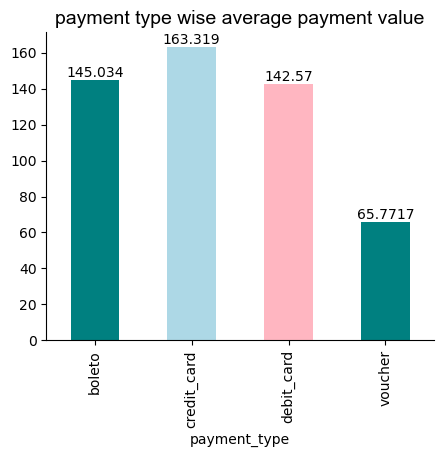

In [115]:
ax = df.groupby("payment_type")["payment_value"].mean().plot(
    kind="bar",
    figsize=(5,4),
    color = ["teal","lightblue","lightpink"],
)
for container in ax.containers:
    ax.bar_label(container)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.set_title( "payment type wise average payment value",
fontsize=14,
fontfamily="Arial"  
 )  


In [116]:
df["payment_installments"].describe()

count    103877.000000
mean          2.853509
std           2.687112
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [120]:
(df["payment_installments"].value_counts(normalize=True)*100).round(2).head(10)

payment_installments
1     50.58
2     11.95
3     10.07
4      6.83
10     5.13
5      5.04
8      4.11
6      3.77
7      1.57
9      0.62
Name: proportion, dtype: float64

50.58% of the payments happens in  first installment 

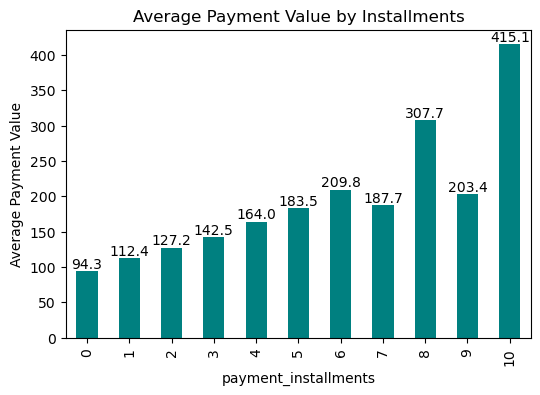

In [127]:
ax = (
    df[df["payment_installments"] <= 10]
    .groupby("payment_installments")["payment_value"]
    .mean()
    .plot(
        kind="bar",
        color="teal",
        figsize=(6,4),
        title="Average Payment Value by Installments"
    )
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.ylabel("Average Payment Value")
plt.show()

Insight: Customers tend to choose more payment installments for higher-value purchases, indicating that installment plans are commonly used for expensive orders.

In [131]:
df.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
Name: payment_value, dtype: float64

credit card payment comtributes to most revenue 

In [144]:
#df.boxplot(column="payment_value")
df[df["payment_value"]==13664.08]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08


In [145]:
df[["payment_installments","payment_value"]].corr()

,payment_installments,payment_value
payment_installments,1.000000,0.330783
payment_value,0.330783,1.000000


In [146]:
df.sort_values(by="payment_value", ascending=False).head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.54
43232,a96610ab360d42a2e5335a3998b4718a,1,credit_card,10,4950.34
70320,b4c4b76c642808cbe472a32b86cddc95,1,credit_card,5,4809.44
6440,199af31afc78c699f0dbf71fb178d4d4,1,credit_card,8,4764.34
67546,8dbc85d1447242f3b127dda390d56e19,1,credit_card,8,4681.78


In [147]:
df.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [12]:
df.to_csv("olist_order_payments_dataset_cle.csv",index = False)

In [11]:
df['payment_value'] = df['payment_value'].astype(float)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103877 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
